In [14]:
from __future__ import print_function, division

import numpy as np
import tensorflow as tf
import tensorflow.keras as K
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import Sequential, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
import scipy.io
import itertools
import time
import shutil
import os


In [15]:
cell_dir='dataset_A/cell_level_label'

In [16]:
X_train = np.load(f'{cell_dir}/X_train.npy')
X_test = np.load(f'{cell_dir}/X_test.npy')
y_train = np.load(f'{cell_dir}/y_train.npy')
y_test = np.load(f'{cell_dir}/y_test.npy')

X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
for i in range(X_train.shape[0]):
    X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
for i in range(X_test.shape[0]):
    X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

X_train_resized = 2 * X_train_resized - 1
X_test_resized = 2 * X_test_resized - 1


(1631, 32, 32, 3)


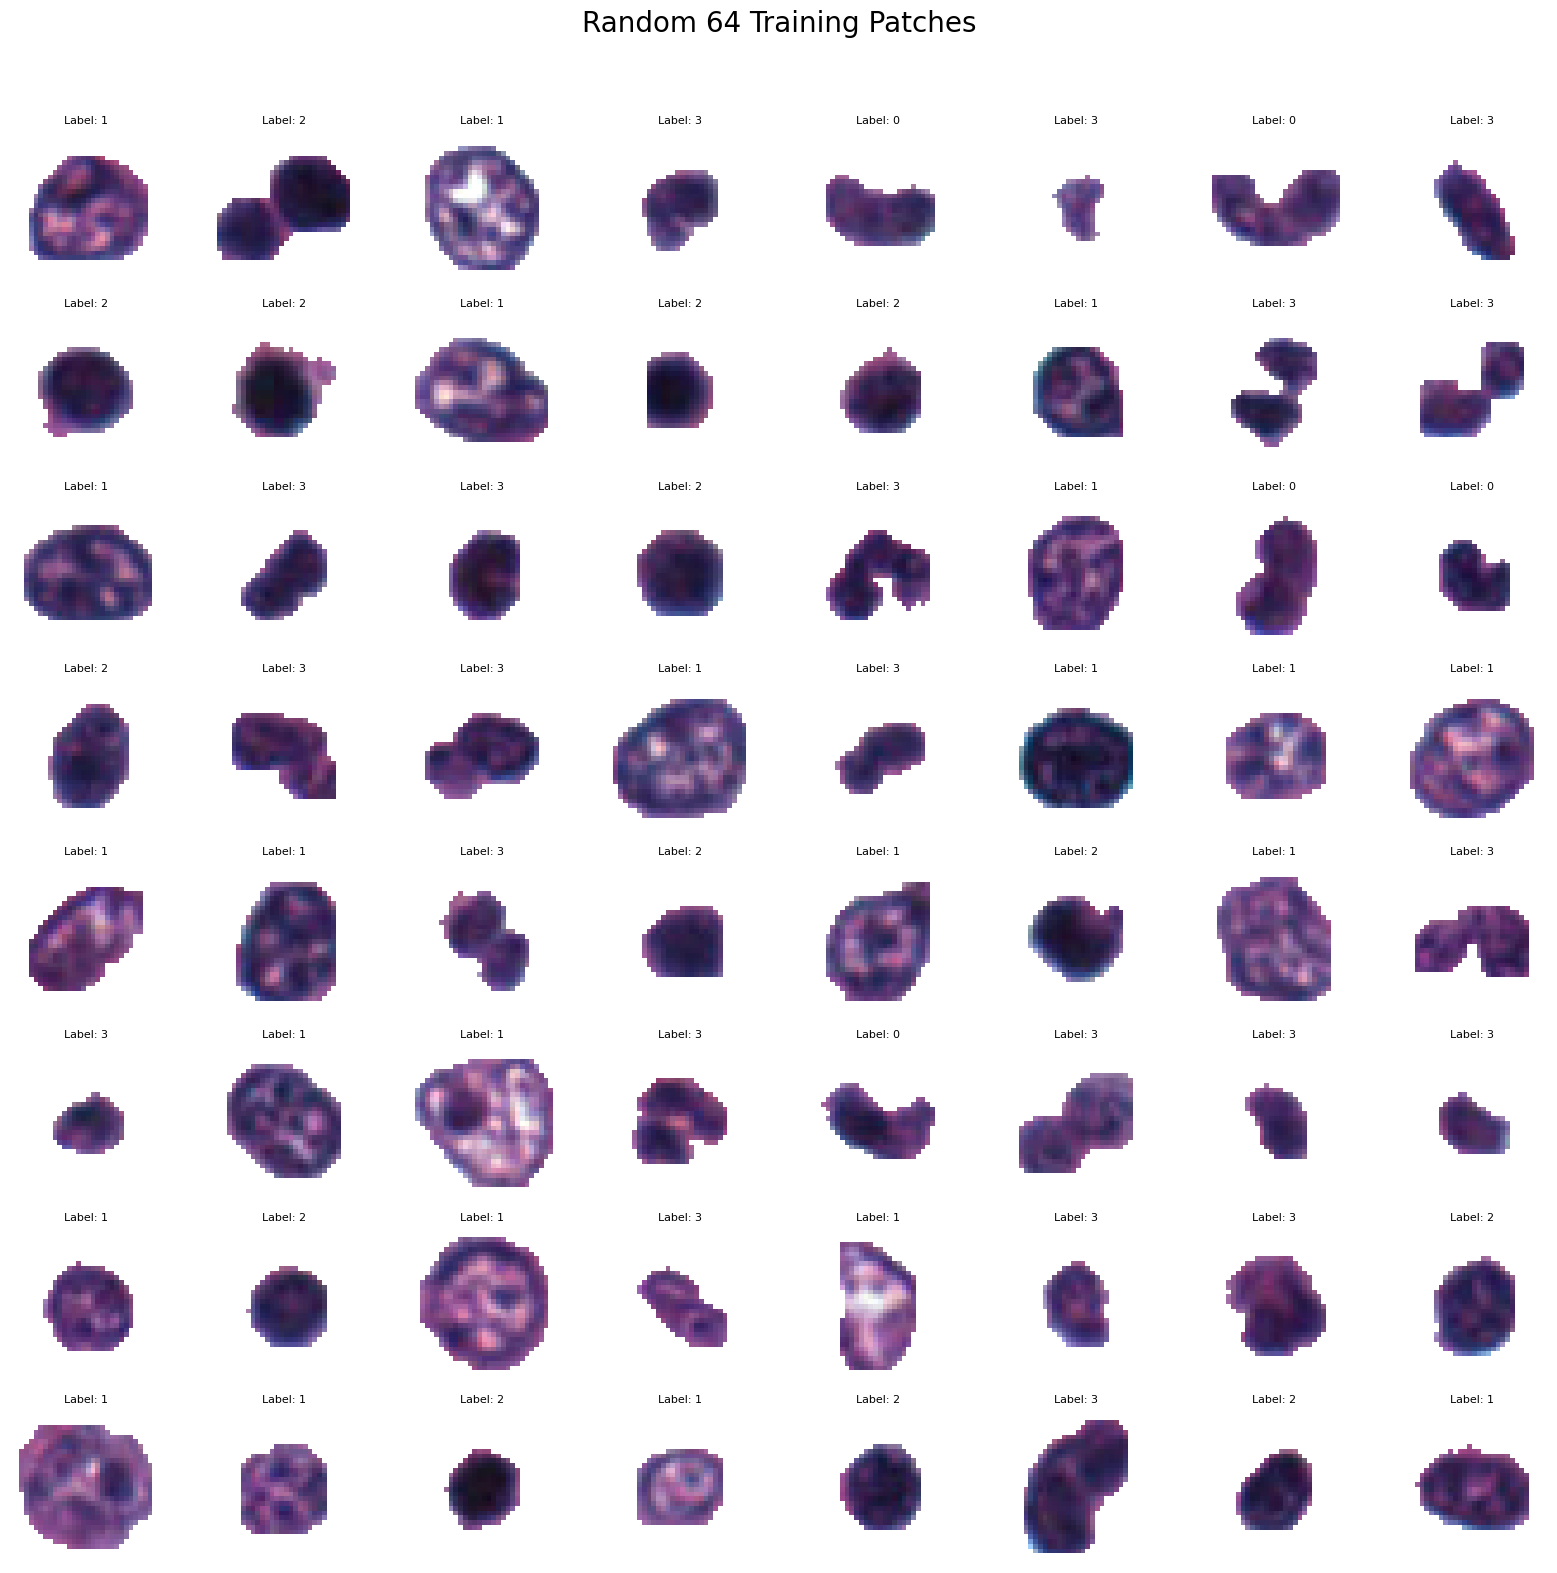

In [17]:
X_train_dis = (X_train_resized + 1) / 2.0
print(X_train_dis.shape)

n_plot = min(64, X_train_dis.shape[0]) 
random_indices = np.random.choice(X_train_dis.shape[0], n_plot, replace=False)
plt.figure(figsize=(16, 16)) 
for idx, random_idx in enumerate(random_indices):
    ax = plt.subplot(8, 8, idx + 1)
    ax.imshow(X_train_dis[random_idx])
    lbl = y_train[random_idx][0] if y_train.ndim > 1 else y_train[random_idx]
    ax.set_title(f"Label: {lbl}", fontsize=8)
    ax.axis('off')

plt.suptitle("Random 64 Training Patches", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
class DCGAN():
    def __init__(self):
        
        self.img_rows = 32
        self.img_cols = 32
        self.channels = 3
        self.img_shape = (self.img_rows, self.img_cols, self.channels)

        self.num_classes = 4
        self.latent_dim = 100
        
        self.training_history = {
                'D_loss': [],
                'D_acc': [],
                'G_loss': [],
                'G_acc': [],
                }       
        

        self.discriminator = self.build_discriminator()
        
        optimizer =  K.optimizers.Adam(learning_rate=0.00002)
        self.discriminator.compile(
                loss=['binary_crossentropy', 'categorical_crossentropy'],
                loss_weights=[0.5, 0.5],
                optimizer=optimizer,
                metrics=['accuracy'])

        self.generator = self.build_generator()
        

        z = K.layers.Input(shape=(self.latent_dim,))
        img = self.generator(z)

        self.discriminator.trainable = False

        valid, _ = self.discriminator(img)
      
        self.combined = Model(z, valid)
        self.combined.compile(loss='binary_crossentropy', optimizer=optimizer)
        
        
        
    def build_generator(self):
        
        model = K.Sequential()

        model.add(K.layers.Dense(128 * 8 * 8, activation="relu", input_dim=self.latent_dim))
        model.add(K.layers.Reshape((8, 8, 128)))
        model.add(K.layers.UpSampling2D())
        model.add(K.layers.Conv2D(128, kernel_size=3, padding="same"))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Activation("relu"))
        model.add(K.layers.UpSampling2D())
        model.add(K.layers.Conv2D(64, kernel_size=3, padding="same"))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.Activation("relu"))
        model.add(K.layers.Conv2D(self.channels, kernel_size=3, padding="same"))
        model.add(K.layers.Activation("tanh"))

        """
        -----------------------------------------------------------------------------------------------
         Generate noise and Image
        -----------------------------------------------------------------------------------------------
        """ 
        noise = K.layers.Input(shape=(self.latent_dim,))
        img = model(noise)
        
        """
        -----------------------------------------------------------------------------------------------
         Return Model
        -----------------------------------------------------------------------------------------------
        """ 
        return Model(noise, img)
    
    
    
    def build_discriminator(self):

        """
        -----------------------------------------------------------------------------------------------
         Model creation for discriminator
        -----------------------------------------------------------------------------------------------
        """ 
        model = K.Sequential()
        
        """
        -----------------------------------------------------------------------------------------------
         Add layers
        -----------------------------------------------------------------------------------------------
        """ 

        model.add(K.layers.Conv2D(32, kernel_size=3, strides=2, input_shape=self.img_shape, padding="same"))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.Conv2D(64, kernel_size=3, strides=2, padding="same"))
        model.add(K.layers.ZeroPadding2D(padding=((0,1),(0,1))))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.Conv2D(128, kernel_size=3, strides=2, padding="same"))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.Conv2D(256, kernel_size=3, strides=1, padding="same"))
        model.add(K.layers.BatchNormalization(momentum=0.8))
        model.add(K.layers.LeakyReLU(alpha=0.2))
        model.add(K.layers.Dropout(0.25))
        model.add(K.layers.Flatten())
        #model.add(K.layers.Dense(1, activation='sigmoid'))

        img = K.layers.Input(shape=self.img_shape)
        features = model(img)

        valid = K.layers.Dense(1, activation="sigmoid")(features)

        label = K.layers.Dense(self.num_classes+1, activation="softmax")(features)
        

        return Model(img, [valid, label])
    
    
    
    def train(self, X_train, y_train, X_test, y_test, epochs, batch_size, save_interval):
        
      
        shutil.rmtree('DCGAN_generated_output', ignore_errors=True)
        os.makedirs("DCGAN_generated_output")

        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))

        for epoch in range(epochs):
            

            idx = np.random.randint(0, X_train.shape[0], batch_size)
            imgs = X_train[idx]

            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            gen_imgs = self.generator.predict(noise)
            
            labels = tf.keras.utils.to_categorical(y_train[idx], num_classes=self.num_classes+1)
            fake_labels = tf.keras.utils.to_categorical(np.full((batch_size, 1), self.num_classes), num_classes=self.num_classes+1)
            
            # Train the discriminator (real classified as ones and generated as zeros)
            d_loss_real = self.discriminator.train_on_batch(imgs, [valid, labels])
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, [fake, fake_labels])
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)            

            g_loss = self.combined.train_on_batch(noise, valid)

            self.training_history["D_loss"].append(d_loss[0]);
            self.training_history["D_acc"].append(100*d_loss[1]);
            self.training_history["G_loss"].append(g_loss);

            print ("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (epoch, d_loss[0], 100*d_loss[3], g_loss))
 
            self.evaluate_discriminator(X_test, y_test)

            if epoch % save_interval == 0:
                self.save_imgs(epoch)
                
                
                
    def evaluate_discriminator(self, X_test, y_test):
        valid = np.ones((y_test.shape[0], 1))
        
        """
        -----------------------------------------------------------------------------------------------
         Convert labels to categorical one-hot encoding
        -----------------------------------------------------------------------------------------------
        """ 
        labels = tf.keras.utils.to_categorical(y_test, num_classes=self.num_classes+1)
        
        """
        -----------------------------------------------------------------------------------------------
         Evaluating the trained Discriminator and print outputs
        -----------------------------------------------------------------------------------------------
        """ 
        scores = self.discriminator.evaluate(X_test, [valid, labels], verbose=0)

        print("Evaluating D [loss:  %.4f, bi-loss: %.4f, cat-loss: %.4f, bi-acc: %.2f%%, cat-acc: %.2f%%]\n" %
              (scores[0], scores[1], scores[2], scores[3]*100, scores[4]*100))

        return (scores[0], scores[3]*100)
    
    
    
    def save_imgs(self, epoch):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise)

        """
        -----------------------------------------------------------------------------------------------
         Rescale images from [-1..1] to [0..1] just to display purposes.
        -----------------------------------------------------------------------------------------------
        """ 
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt, :,:,0])
                axs[i,j].axis('off')
                cnt += 1
        
        """
        -----------------------------------------------------------------------------------------------
          Save generator image for each epoch
        -----------------------------------------------------------------------------------------------
        """ 
        fig.savefig("./DCGAN_generated_output/dcgan_%d.png" % epoch)
        plt.close()
        
        
    
    def save_model(self):

        def save(model, model_name):
            
            """
            -----------------------------------------------------------------------------------------------
            Save weights
            -----------------------------------------------------------------------------------------------
            """
            model_path = "./DCGAN_saved_models/%s.json" % model_name
            weights_path = "./DCGAN_saved_models/%s_weights.hdf5" % model_name
            options = {"file_arch": model_path,
                        "file_weight": weights_path}
            json_string = model.to_json()
            open(options['file_arch'], 'w').write(json_string)
            model.save_weights(options['file_weight'])

        shutil.rmtree('DCGAN_saved_models', ignore_errors=True)
        os.makedirs("DCGAN_saved_models")
        
        """
        -----------------------------------------------------------------------------------------------
          Save models
        -----------------------------------------------------------------------------------------------
        """         
        save(self.generator, "DC_gan_generator")
        save(self.discriminator, "DC_gan_discriminator")
        save(self.combined, "DC_gan_adversarial")
        
        
    
    def plot_training_history(self):
        
        """
        -----------------------------------------------------------------------------------------------
          Plot training history
        -----------------------------------------------------------------------------------------------
        """
        fig, axs = plt.subplots(1,2,figsize=(15,5))
        plt.title('Training History')
        
        """
        -----------------------------------------------------------------------------------------------
          Summarize history for G and D accuracy
        -----------------------------------------------------------------------------------------------
        """
        axs[0].plot(range(1,len(self.training_history['D_acc'])+1),self.training_history['D_acc'])
        axs[0].plot(range(1,len(self.training_history['G_acc'])+1),self.training_history['G_acc'])
        axs[0].set_title('D and G Accuracy')
        axs[0].set_ylabel('Accuracy')
        axs[0].set_xlabel('Epoch')
        # axs[0].set_xticks(np.arange(1,len(self.training_history['D_acc'])+1),len(self.training_history['D_acc'])/10)
        axs[0].set_yticks([n for n in range(0, 101,10)])
        axs[0].legend(['Discriminator', 'Generator'], loc='best')
        
        """
        -----------------------------------------------------------------------------------------------
          Summarize history for G and D los
        -----------------------------------------------------------------------------------------------
        """
        axs[1].plot(range(1,len(self.training_history['D_loss'])+1),self.training_history['D_loss'])
        axs[1].plot(range(1,len(self.training_history['G_loss'])+1),self.training_history['G_loss'])
        axs[1].set_title('D and G Loss')
        axs[1].set_ylabel('Loss')
        axs[1].set_xlabel('Epoch')
        # axs[1].set_xticks(np.arange(1,len(self.training_history['G_loss'])+1),len(self.training_history['G_loss'])/10)
        axs[1].legend(['Discriminator', 'Generator'], loc='best')
        
        """
        -----------------------------------------------------------------------------------------------
         Plot graphs
        -----------------------------------------------------------------------------------------------
        """
        plt.show()
        
        
        
    def predict(self, X_test, y_test):
        """
        -----------------------------------------------------------------------------------------------
        Generate predictions from the discriminator over the testing dataset
        -----------------------------------------------------------------------------------------------
        """
        # 1) raw discriminator output
        y_pred_out = self.discriminator.predict(X_test)

        # 2) discriminator.predict may return [real_fake, class_logits]
        if isinstance(y_pred_out, list):
            # assume second head is the classification logits
            class_logits = y_pred_out[1]
        else:
            class_logits = y_pred_out

        # 3) if the discriminator appended an extra "real/fake" class at the end,
        #    slice it off so we're left with num_classes columns
        if class_logits.shape[1] == self.num_classes + 1:
            class_probs = class_logits[:, : self.num_classes]
        else:
            class_probs = class_logits

        print(f"Shape of class_probs: {class_probs.shape}")  # should be (n_samples, num_classes)

        # 4) one-hot encode y_test for average_precision_score
        y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=self.num_classes)

        # 5) compute Average Precision (macro)
        avep = average_precision_score(y_test_oh, class_probs, average='macro')
        print(f"\nAveP: {avep * 100:.2f}%\n")

        # 6) derive hard labels for accuracy / classification_report
        y_pred_labels = np.argmax(class_probs, axis=1)

        # 7) overall accuracy
        acc = accuracy_score(y_test, y_pred_labels)
        print(f"Overall accuracy: {acc * 100:.2f}%\n")

        # 8) classification report
        unique_classes = np.unique(y_test)
        class_names = [f"Class {i}" for i in unique_classes]
        print(
            "Classification report:\n"
            + classification_report(
                y_test,
                y_pred_labels,
                target_names=class_names,
                zero_division=0,
            )
        )

        # 9) confusion matrix
        cm = confusion_matrix(y_test, y_pred_labels)
        self.plot_confusion_matrix(cm, class_names)


    def plot_confusion_matrix(self,cm, classes,
                            normalize=False,
                            title='Confusion matrix',
                            cmap=plt.cm.Blues):
        """
        -----------------------------------------------------------------------------------------------
        Prints and plots the confusion matrix
        -----------------------------------------------------------------------------------------------
        """
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)

        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        
    

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    -----------------------------------------------------------------------------------------------
     Prints and plots the confusion matrix
    -----------------------------------------------------------------------------------------------
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
        
def load_cell_dataset_npy(cell_dir):
    """
    -----------------------------------------------------------------------------------------------
     Load pre-cropped cell images from .npy files
    -----------------------------------------------------------------------------------------------
    """
    X_train = np.load(f'{cell_dir}/X_train.npy')
    X_test = np.load(f'{cell_dir}/X_test.npy')
    y_train = np.load(f'{cell_dir}/y_train.npy')
    y_test = np.load(f'{cell_dir}/y_test.npy')

    """
    -----------------------------------------------------------------------------------------------
     Resize images to 32x32 if needed
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
    for i in range(X_train.shape[0]):
        X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

    X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
    for i in range(X_test.shape[0]):
        X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

    """
    -----------------------------------------------------------------------------------------------
     Normalize images from [0..1] to [-1..1]
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = 2 * X_train_resized - 1
    X_test_resized = 2 * X_test_resized - 1

    return X_train_resized, y_train, X_test_resized, y_test


In [19]:
X_train, y_train, X_test, y_test = load_cell_dataset_npy('dataset_A/cell_level_label')
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))
gan=DCGAN()

Unique labels in y_train: [0 1 2 3]
Unique labels in y_test: [0 1 2 3]


In [20]:
start = time.time() 
gan.train(X_train, y_train, X_test, y_test, epochs=2000, batch_size=32, save_interval=10)
end = time.time()
print ("\nTraining time: %0.1f minutes \n" % ((end-start) / 60))
gan.save_model()

1/1 [==============================] - 0s 190ms/step
0 [D loss: 1.602818, acc.: 43.75%] [G loss: 0.680369]
Evaluating D [loss:  1.1569, bi-loss: 0.6939, cat-loss: 1.6200, bi-acc: 48.35%, cat-acc: 35.99%]

1/1 [==============================] - 0s 50ms/step
1 [D loss: 1.673644, acc.: 46.88%] [G loss: 0.692587]
Evaluating D [loss:  1.1563, bi-loss: 0.6779, cat-loss: 1.6347, bi-acc: 76.10%, cat-acc: 35.44%]

1/1 [==============================] - 0s 79ms/step
2 [D loss: 1.511781, acc.: 48.44%] [G loss: 0.687600]
Evaluating D [loss:  1.1472, bi-loss: 0.6483, cat-loss: 1.6461, bi-acc: 91.21%, cat-acc: 35.16%]

1/1 [==============================] - 0s 87ms/step
3 [D loss: 1.453799, acc.: 45.31%] [G loss: 0.756179]
Evaluating D [loss:  1.1356, bi-loss: 0.6188, cat-loss: 1.6524, bi-acc: 95.05%, cat-acc: 32.42%]

1/1 [==============================] - 0s 61ms/step
4 [D loss: 1.442532, acc.: 46.88%] [G loss: 0.593613]
Evaluating D [loss:  1.1213, bi-loss: 0.5831, cat-loss: 1.6595, bi-acc: 96.43

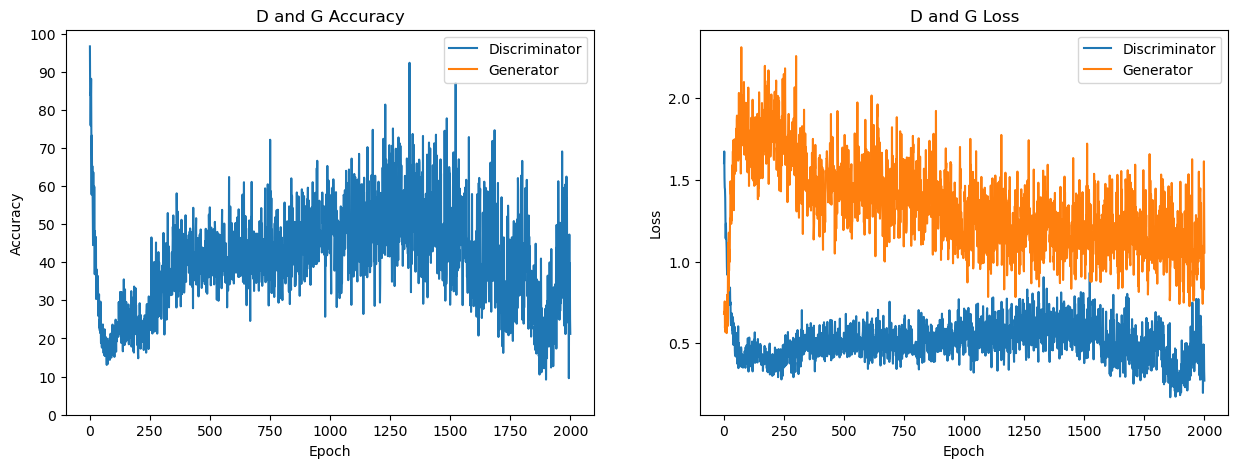

In [21]:
gan.plot_training_history()

In [22]:
gan.evaluate_discriminator(X_test,y_test)

Evaluating D [loss:  0.5196, bi-loss: 0.2302, cat-loss: 0.8089, bi-acc: 95.60%, cat-acc: 74.45%]



(0.5195567607879639, 95.60439586639404)

12/12 [==============================] - 1s 58ms/step
Shape of class_probs: (364, 4)

AveP: 70.67%

Overall accuracy: 79.95%

Classification report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         9
     Class 1       0.80      0.90      0.85       132
     Class 2       0.68      0.90      0.78        92
     Class 3       0.95      0.68      0.79       131

    accuracy                           0.80       364
   macro avg       0.61      0.62      0.60       364
weighted avg       0.80      0.80      0.79       364



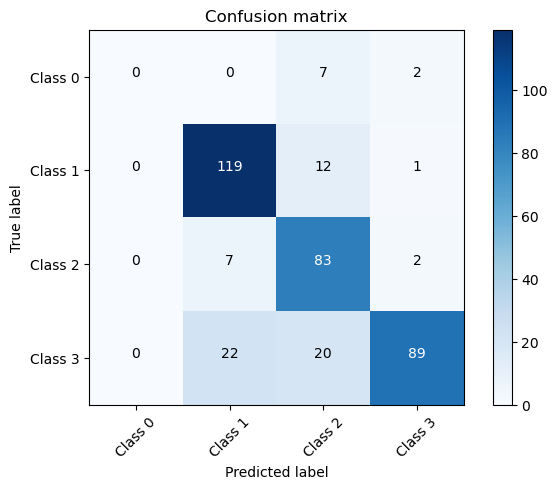

In [23]:
gan.predict(X_test,y_test)

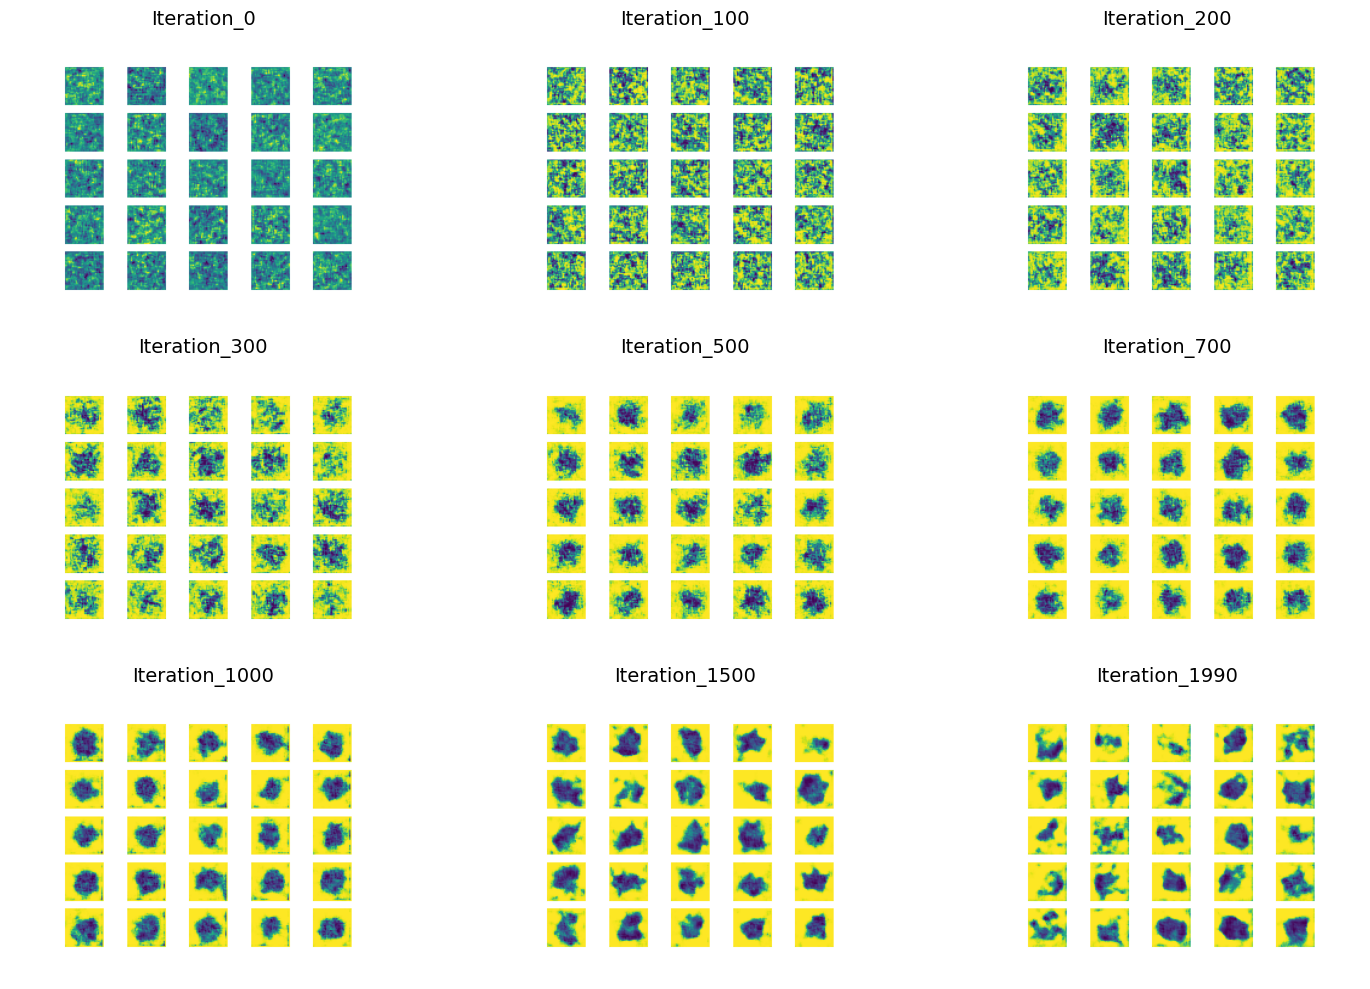

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Replace the path with your image file's path
files = [0, 100, 200, 300,500, 700,1000, 1500, 1990]

# Create a figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # Adjust the grid size as needed
axes = axes.ravel()  # Flatten the axes array for easy indexing

# Loop through the files and plot each image
for i, file in enumerate(files):
    # Read the image
    img = mpimg.imread(f'DCGAN_generated_output/dcgan_{file}.png')
    
    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f'Iteration_{file}', fontsize=14)
    axes[i].axis('off')  # Optional: hides the axes

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()
